In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import pandas as pd
import astropy as ap
from scipy.integrate import quad

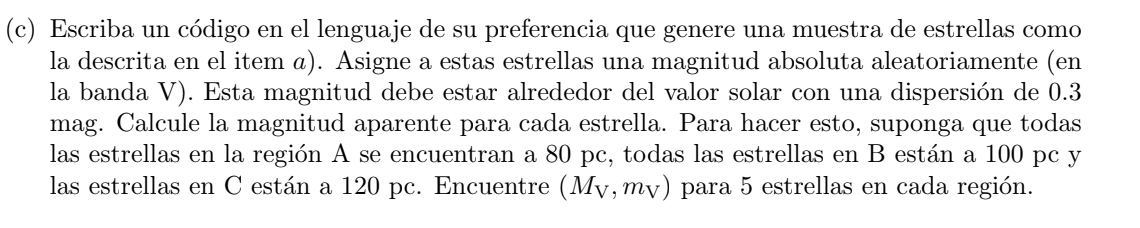

In [2]:
MA_norm = st.norm.rvs(loc=4.78,scale=0.3,size=5)
MA_unif = st.uniform.rvs(loc=4.48,scale=0.6,size=5)

MB_norm = st.norm.rvs(loc=4.78,scale=0.3,size=5)
MB_unif = st.uniform.rvs(loc=4.48,scale=0.6,size=5)

MC_norm = st.norm.rvs(loc=4.78,scale=0.3,size=5)
MC_unif = st.uniform.rvs(loc=4.48,scale=0.6,size=5)

dA = 80
dB = 100
dC = 120

def apparent_magnitude(M,d):
    return M + 5*np.log10(d) - 5

mA_norm = apparent_magnitude(MA_norm,dA)
mA_unif = apparent_magnitude(MA_unif,dA)

mB_norm = apparent_magnitude(MB_norm,dB)
mB_unif = apparent_magnitude(MB_unif,dB)

mC_norm = apparent_magnitude(MC_norm,dC)
mC_unif = apparent_magnitude(MC_unif,dC)

print('----------------------------')
for M,m in zip(MA_norm,mA_norm):
    print(f'Región A (normal): ({M},{m})')
for M,m in zip(MA_unif,mA_unif):
    print(f'Región A (uniforme): ({M},{m})')
print('----------------------------')
for M,m in zip(MB_norm,mB_norm):
    print(f'Región B (normal): ({M},{m})')
for M,m in zip(MB_unif,mB_unif):
    print(f'Región B (uniforme): ({M},{m})')
print('----------------------------')
for M,m in zip(MC_norm,mC_norm):
    print(f'Región C (normal): ({M},{m})')
for M,m in zip(MC_unif,mC_unif):
    print(f'Región C (uniforme): ({M},{m})')
print('----------------------------')

----------------------------
Región A (normal): (4.972400629479962,9.487850564439679)
Región A (normal): (4.846692261906055,9.362142196865772)
Región A (normal): (4.961321777343508,9.476771712303226)
Región A (normal): (4.50801192373783,9.023461858697548)
Región A (normal): (4.574083840653025,9.089533775612743)
Región A (uniforme): (4.776373520683476,9.291823455643193)
Región A (uniforme): (4.552962883410845,9.068412818370561)
Región A (uniforme): (4.858513572434084,9.373963507393801)
Región A (uniforme): (5.020105687058333,9.53555562201805)
Región A (uniforme): (4.668153083423671,9.183603018383387)
----------------------------
Región B (normal): (5.018413927794225,10.018413927794224)
Región B (normal): (5.043792745109745,10.043792745109744)
Región B (normal): (5.005501651973773,10.005501651973773)
Región B (normal): (4.7650733917744414,9.765073391774441)
Región B (normal): (4.871666798190074,9.871666798190073)
Región B (uniforme): (4.7483392062103675,9.748339206210368)
Región B (unifo

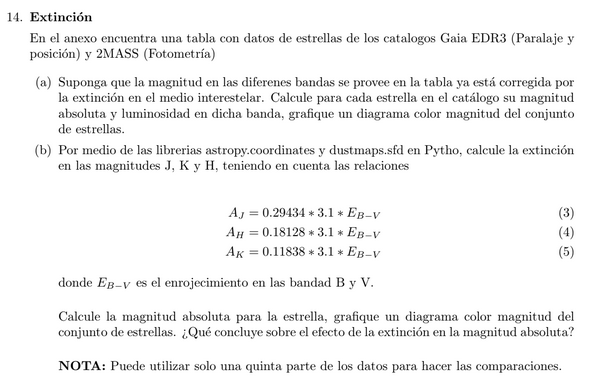

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/SantiagoJulioD/Galaxias/refs/heads/main/Datos.csv')
data

,Ids,Ra[°],Dec[°],Plx[mas],ePlx[mas],J[mag],H[mag],K[mag]
0,23575592-4052404,359.483176,-40.877908,1.1030,0.1811,16.339,15.453,15.173
1,23575313-4051375,359.471374,-40.860441,2.3385,0.0168,12.674,12.220,12.052
2,23583586-4100115,359.649484,-41.003224,1.4465,0.0654,13.912,13.376,13.252
3,23583824-4058449,359.659359,-40.979199,0.8582,0.0652,15.369,14.640,14.691
4,23584088-4058417,359.670386,-40.978267,1.2051,0.0764,15.213,14.513,14.316
...,...,...,...,...,...,...,...,...
53149,00000598-3312438,0.024908,-33.212177,2.1658,0.2040,16.033,15.389,15.209
53150,00000244-3311343,0.010155,-33.192909,0.6990,0.1031,15.903,15.551,14.891
53151,00000021-3311187,0.000832,-33.188508,0.7691,0.2036,16.609,15.749,15.299
53152,00000152-3309522,0.006349,-33.164506,0.2250,0.1099,16.201,15.915,15.563


In [4]:
data['d[pc]'] = 1/(data['Plx[mas]']*1e-3)
data

,Ids,Ra[°],Dec[°],Plx[mas],ePlx[mas],J[mag],H[mag],K[mag],d[pc]
0,23575592-4052404,359.483176,-40.877908,1.1030,0.1811,16.339,15.453,15.173,906.618314
1,23575313-4051375,359.471374,-40.860441,2.3385,0.0168,12.674,12.220,12.052,427.624546
2,23583586-4100115,359.649484,-41.003224,1.4465,0.0654,13.912,13.376,13.252,691.323885
3,23583824-4058449,359.659359,-40.979199,0.8582,0.0652,15.369,14.640,14.691,1165.229550
4,23584088-4058417,359.670386,-40.978267,1.2051,0.0764,15.213,14.513,14.316,829.806655
...,...,...,...,...,...,...,...,...,...
53149,00000598-3312438,0.024908,-33.212177,2.1658,0.2040,16.033,15.389,15.209,461.723151
53150,00000244-3311343,0.010155,-33.192909,0.6990,0.1031,15.903,15.551,14.891,1430.615165
53151,00000021-3311187,0.000832,-33.188508,0.7691,0.2036,16.609,15.749,15.299,1300.221038
53152,00000152-3309522,0.006349,-33.164506,0.2250,0.1099,16.201,15.915,15.563,4444.444444


In [5]:
def absMag(m,d):
    M = m - 5*np.log10(d) + 5
    return M

In [6]:
data['MJ[mag]'] = absMag(data['J[mag]'],data['d[pc]'])
data['MH[mag]'] = absMag(data['H[mag]'],data['d[pc]'])
data['MK[mag]'] = absMag(data['K[mag]'],data['d[pc]'])
data

,Ids,Ra[°],Dec[°],Plx[mas],ePlx[mas],J[mag],H[mag],K[mag],d[pc],MJ[mag],MH[mag],MK[mag]
0,23575592-4052404,359.483176,-40.877908,1.1030,0.1811,16.339,15.453,15.173,906.618314,6.551878,5.665878,5.385878
1,23575313-4051375,359.471374,-40.860441,2.3385,0.0168,12.674,12.220,12.052,427.624546,4.518687,4.064687,3.896687
2,23583586-4100115,359.649484,-41.003224,1.4465,0.0654,13.912,13.376,13.252,691.323885,4.713592,4.177592,4.053592
3,23583824-4058449,359.659359,-40.979199,0.8582,0.0652,15.369,14.640,14.691,1165.229550,5.036943,4.307943,4.358943
4,23584088-4058417,359.670386,-40.978267,1.2051,0.0764,15.213,14.513,14.316,829.806655,5.618115,4.918115,4.721115
...,...,...,...,...,...,...,...,...,...,...,...,...
53149,00000598-3312438,0.024908,-33.212177,2.1658,0.2040,16.033,15.389,15.209,461.723151,7.711092,7.067092,6.887092
53150,00000244-3311343,0.010155,-33.192909,0.6990,0.1031,15.903,15.551,14.891,1430.615165,5.125386,4.773386,4.113386
53151,00000021-3311187,0.000832,-33.188508,0.7691,0.2036,16.609,15.749,15.299,1300.221038,6.038914,5.178914,4.728914
53152,00000152-3309522,0.006349,-33.164506,0.2250,0.1099,16.201,15.915,15.563,4444.444444,2.961913,2.675913,2.323913


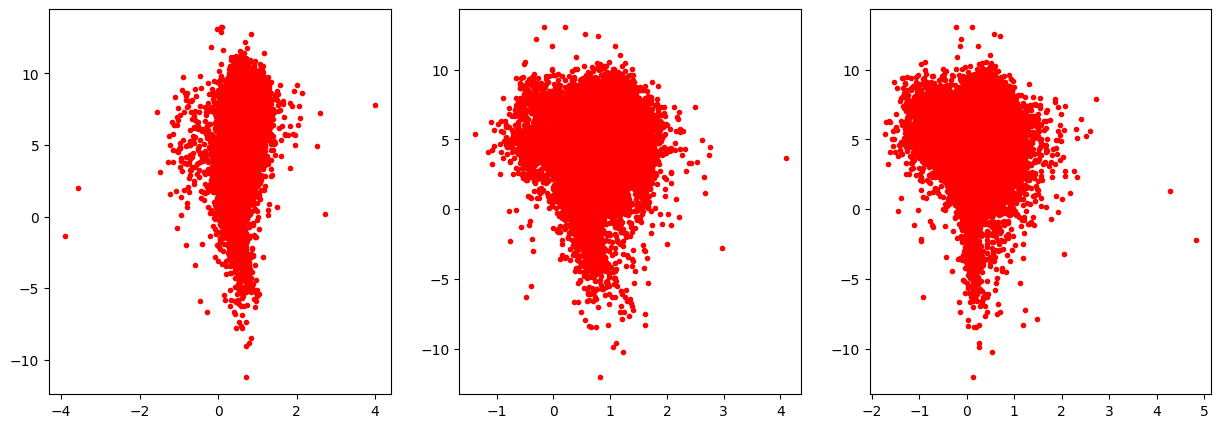

In [7]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].plot(data['J[mag]']-data['H[mag]'],data['MJ[mag]'],'r.')
ax[1].plot(data['J[mag]']-data['K[mag]'],data['MK[mag]'],'r.')
ax[2].plot(data['H[mag]']-data['K[mag]'],data['MK[mag]'],'r.')

In [8]:
absMag(9.71,10.7e3)

-5.4369188884260495

In [9]:
def R25(M):
    return 10**(-0.249*M-4)

In [10]:
R25(-18.06)

3.14007484653584

In [11]:
R25(-18.57)

4.206588207288499

In [12]:
R25(-5.44)

0.002262351073531479

In [13]:
def incomp_gamma(a,x):
    f = lambda t: t**(a-1)*np.exp(-t)
    return quad(f,x,np.inf)[0]

incomp_gamma = np.vectorize(incomp_gamma)

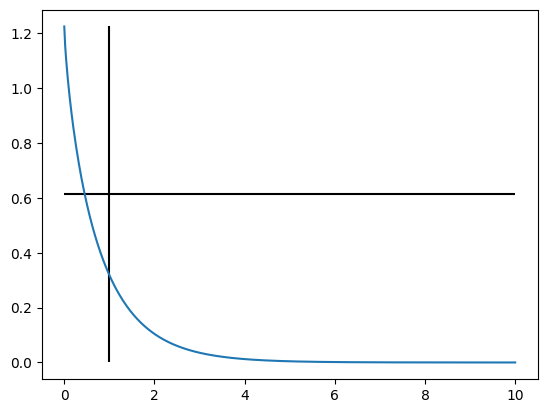

In [14]:
xs = np.linspace(0,10,500)
ys = incomp_gamma(0.75,xs)
plt.vlines(1,0,incomp_gamma(0.75,0),colors='k')
plt.hlines(0.5*incomp_gamma(0.75,0),0,10,colors='k')
plt.plot(xs,ys)

/tmp/ipykernel_84829/3984405051.py:3: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return quad(f,x,np.inf)[0]


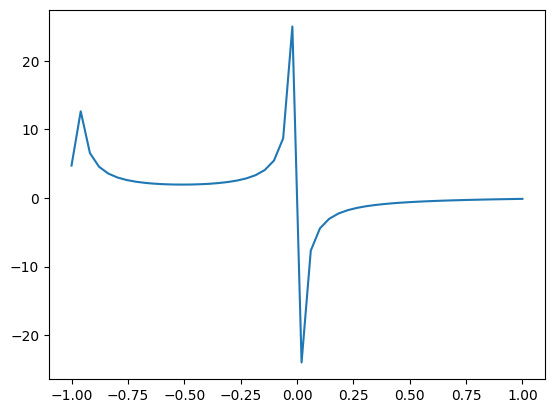

In [15]:
a_s = np.linspace(-1,1)
ys = incomp_gamma(a_s,1)-incomp_gamma(a_s,0)/2
plt.plot(a_s,ys)